# **Baseline Models para Previsão de Churn** 🤖

# 📏 1. Definição das Métricas de Avaliação

Nesta etapa, são definidas as métricas técnicas e de negócio que serão utilizadas para avaliar o desempenho dos modelos baseline no problema de churn.

💡 **Justificativa das métricas:**

Como a variável alvo apresenta desbalanceamento entre clientes que permaneceram e clientes que realizaram churn, a análise do desempenho dos modelos não será baseada apenas em accuracy.

Serão utilizadas métricas como **precision, recall, F1-score, ROC-AUC e PR-AUC**, pois elas permitem avaliar melhor a capacidade do modelo de identificar corretamente os clientes com maior risco de churn.

O **recall** será especialmente importante neste contexto, já que representa a proporção de clientes que realmente cancelaram e que foram corretamente identificados pelo modelo. Já o **F1-score** será utilizado como uma métrica de equilíbrio entre precision e recall.

Além disso, métricas como **ROC-AUC** e **PR-AUC** serão empregadas para comparar a capacidade de separação entre as classes, sendo a PR-AUC particularmente útil em cenários com desbalanceamento.

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [6]:
def avaliar_modelo(nome_modelo, y_true, y_pred, y_prob):
    resultados = {
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob)
    }

    print(f"Modelo: {nome_modelo}")
    print(f"Accuracy:  {resultados['accuracy']:.4f}")
    print(f"Precision: {resultados['precision']:.4f}")
    print(f"Recall:    {resultados['recall']:.4f}")
    print(f"F1-score:  {resultados['f1_score']:.4f}")
    print(f"ROC-AUC:   {resultados['roc_auc']:.4f}")
    print(f"PR-AUC:    {resultados['pr_auc']:.4f}")

    return resultados

In [7]:
# Teste simples da função
y_true = [0, 1, 0, 1, 1]
y_pred = [0, 1, 0, 0, 1]
y_prob = [0.1, 0.8, 0.2, 0.3, 0.9]

resultado_teste = avaliar_modelo("Teste", y_true, y_pred, y_prob)

Modelo: Teste
Accuracy:  0.8000
Precision: 1.0000
Recall:    0.6667
F1-score:  0.8000
ROC-AUC:   1.0000
PR-AUC:    1.0000


💡 **Conclusão da etapa de métricas:**

Considerando o objetivo de identificar clientes com maior risco de churn, serão priorizadas métricas que avaliem corretamente a capacidade de detecção da classe positiva, especialmente **recall**, **F1-score**, **ROC-AUC** e **PR-AUC**. Essas métricas serão utilizadas nas próximas etapas para comparar os modelos baseline e verificar se eles apresentam desempenho superior a um classificador ingênuo.

# 🧹 2. Preparação dos Dados

Nesta etapa, os dados serão preparados para a construção dos modelos baseline, incluindo seleção da variável alvo, separação entre variáveis explicativas e target, divisão entre treino e teste e definição do pré-processamento.

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [10]:
df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [11]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [12]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [14]:
y = df['Churn Value']
y.value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [15]:
colunas_excluir = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Value',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

X = df.drop(columns=colunas_excluir)

In [16]:
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

X.head()

Dimensão de X: (7043, 21)
Dimensão de y: (7043,)


,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30


In [17]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print("Colunas numéricas:")
print(numeric_features)

print("\nColunas categóricas:")
print(categorical_features)

Colunas numéricas:
['Zip Code', 'Tenure Months', 'Monthly Charges', 'Total Charges']

Colunas categóricas:
['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 21)
X_test: (1409, 21)
y_train: (5634,)
y_test: (1409,)


In [20]:
from sklearn.impute import SimpleImputer

In [21]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [22]:
print("Pré-processamento configurado com sucesso.")

Pré-processamento configurado com sucesso.


💡 **Observação:**

Nesta etapa, foi realizada a preparação dos dados para treinamento dos modelos baseline. A variável alvo definida foi **`Churn Value`**, por já se encontrar em formato binário adequado para classificação.

Também foram removidas colunas com potencial de vazamento de informação, baixa utilidade analítica ou caráter apenas identificador, como `CustomerID`, `Count`, `Churn Label`, `Churn Score`, `CLTV` e `Churn Reason`.

As variáveis explicativas foram separadas entre numéricas e categóricas, permitindo a construção de um pipeline de pré-processamento com tratamento de valores ausentes, padronização das variáveis numéricas e codificação das variáveis categóricas por meio de **One-Hot Encoding**.

A variável alvo apresenta desbalanceamento entre as classes, com maior concentração de clientes que não realizaram churn. Esse comportamento reforça a necessidade de utilização de métricas além da accuracy, como recall, F1-score e PR-AUC, que são mais adequadas para avaliar o desempenho do modelo nesse contexto.

A base foi dividida em conjuntos de treino e teste na proporção de 80/20, mantendo a distribuição da variável alvo por meio da estratificação. Após a remoção de colunas irrelevantes e com potencial de vazamento de informação, o conjunto de dados final utilizado para modelagem contém 21 variáveis explicativas.

Por fim, a base foi dividida em conjuntos de treino e teste com estratificação da variável alvo, garantindo a preservação da proporção entre as classes em ambas as amostras.

# 🤖 3. Modelo Baseline com DummyClassifier

Nesta etapa, será treinado um classificador ingênuo como baseline inicial, com o objetivo de estabelecer uma referência mínima de desempenho para comparação com modelos mais elaborados.

In [23]:
from sklearn.dummy import DummyClassifier

In [24]:
dummy_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

In [25]:
dummy_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [26]:
y_pred_dummy = dummy_model.predict(X_test)
y_prob_dummy = dummy_model.predict_proba(X_test)[:, 1]

In [27]:
resultado_dummy = avaliar_modelo("DummyClassifier", y_test, y_pred_dummy, y_prob_dummy)

Modelo: DummyClassifier
Accuracy:  0.7346
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC-AUC:   0.5000
PR-AUC:    0.2654


In [29]:
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
cm_dummy

array([[1035,    0],
       [ 374,    0]])

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

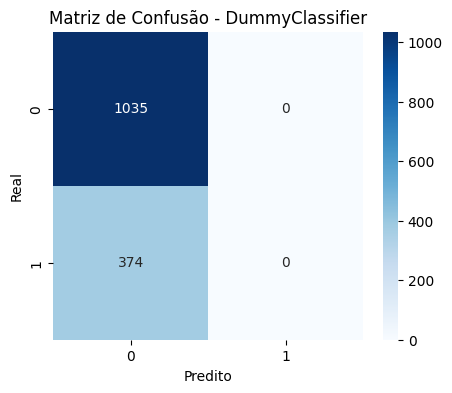

In [33]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - DummyClassifier')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [34]:
print(classification_report(y_test, y_pred_dummy, zero_division=0))

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



💡 **Observação:**

O DummyClassifier, configurado para prever sempre a classe majoritária, apresentou **accuracy de 73,46%**, valor que reflete diretamente o desbalanceamento da base, já que a maior parte dos clientes não realizou churn.

Apesar dessa accuracy aparentemente razoável, o modelo apresentou **precision, recall e F1-score iguais a zero para a classe de churn**, demonstrando incapacidade total de identificar clientes que realmente cancelaram o serviço.

A matriz de confusão confirma esse comportamento, mostrando que todos os registros foram classificados como não churn. Dessa forma, o modelo acerta apenas os casos da classe majoritária e falha completamente no principal objetivo do projeto, que é detectar clientes com risco de cancelamento.

Esse resultado reforça a importância de utilizar métricas além da accuracy em problemas desbalanceados e justifica a necessidade de modelos mais elaborados, como a Regressão Logística, para capturar padrões relevantes nos dados.

# 🤖 4. Modelo Baseline com Regressão Logística
Nesta etapa, será treinado um modelo de Regressão Logística como baseline supervisionado, com o objetivo de comparar seu desempenho com o DummyClassifier e verificar sua capacidade de identificar clientes com risco de churn.

In [35]:
from sklearn.linear_model import LogisticRegression

In [37]:
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [38]:
logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [39]:
y_pred_logreg = logreg_model.predict(X_test)
y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]

In [41]:
resultado_logreg = avaliar_modelo("Logistic Regression", y_test, y_pred_logreg, y_prob_logreg)

Modelo: Logistic Regression
Accuracy:  0.7899
Precision: 0.6161
Recall:    0.5535
F1-score:  0.5831
ROC-AUC:   0.8405
PR-AUC:    0.6368


In [42]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_logreg

array([[906, 129],
       [167, 207]])

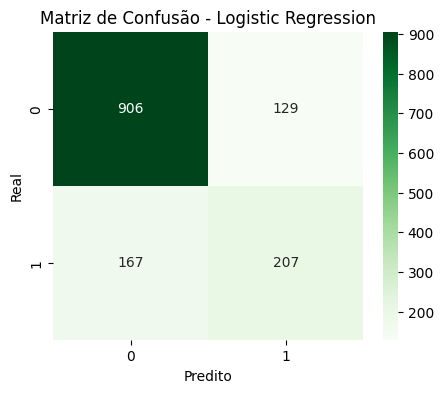

In [43]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Logistic Regression')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [44]:
print(classification_report(y_test, y_pred_logreg, zero_division=0))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [45]:
resultados_comparacao = pd.DataFrame([resultado_dummy, resultado_logreg])
resultados_comparacao

,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,DummyClassifier,0.734564,0.000000,0.000000,0.000000,0.500000,0.265436
1,Logistic Regression,0.789922,0.616071,0.553476,0.583099,0.840453,0.636820


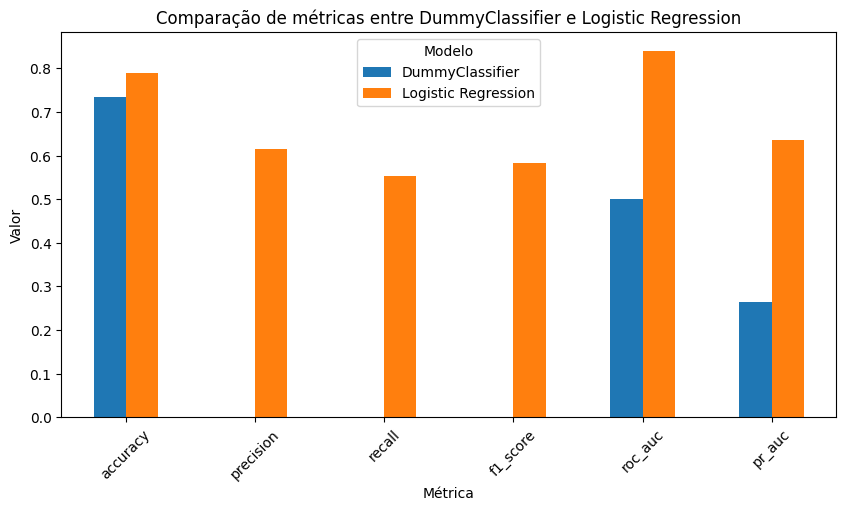

In [46]:
metricas_plot = resultados_comparacao.set_index('modelo')[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']]

metricas_plot.T.plot(kind='bar', figsize=(10,5))
plt.title('Comparação de métricas entre DummyClassifier e Logistic Regression')
plt.ylabel('Valor')
plt.xlabel('Métrica')
plt.xticks(rotation=45)
plt.legend(title='Modelo')
plt.show()

💡 **Observação:**

A Regressão Logística apresentou desempenho significativamente superior ao DummyClassifier, demonstrando capacidade real de identificar padrões associados ao churn dos clientes.

O modelo obteve **accuracy de 78,99%**, superando o baseline ingênuo, mas o principal ganho foi observado nas métricas voltadas à classe positiva. A Regressão Logística alcançou **precision de 61,61%**, **recall de 55,35%** e **F1-score de 58,31%**, enquanto o DummyClassifier havia apresentado valores nulos nessas métricas para churn.

Em termos de separação entre as classes, o modelo também apresentou **ROC-AUC de 0,8405** e **PR-AUC de 0,6368**, indicando bom poder discriminativo e desempenho consistente em um cenário de classes desbalanceadas.

A matriz de confusão mostra que o modelo conseguiu identificar corretamente **207 clientes com churn**, ao mesmo tempo em que manteve boa capacidade de classificação da classe majoritária. Isso representa um avanço expressivo em relação ao DummyClassifier, que classificava todos os clientes como não churn.

De forma geral, os resultados mostram que as variáveis selecionadas possuem poder preditivo relevante e que a Regressão Logística se estabelece como um baseline supervisionado adequado para o problema, servindo como referência para comparações com modelos mais avançados nas próximas etapas do projeto.

# 🏁 5. Conclusão

A comparação entre os modelos baseline mostrou que a Regressão Logística apresentou desempenho claramente superior ao DummyClassifier em todas as métricas relevantes para o problema de churn.

Enquanto o DummyClassifier apenas reproduziu a classe majoritária, a Regressão Logística conseguiu identificar clientes com risco real de cancelamento, alcançando ganhos importantes em **recall, F1-score, ROC-AUC e PR-AUC**.

Esses resultados indicam que os dados possuem poder preditivo e que a Regressão Logística constitui uma baseline supervisionada adequada para servir de referência nas próximas etapas do projeto.